In [ ]:
import pandas as pd
import os

# List of file paths (including new ones)
file_paths = [
    r"C:\Users\TrevorWhite\Downloads\RE_sec_23.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_sec_22.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_sec_21.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_b12_21.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_b12_22.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_b12_23.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_b12_24.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_wcc_21.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_wcc_22.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_WCC_23.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_WCC_24.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_acc_24.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_acc_23.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_acc_22.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_acc_21.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_bw_21.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_bw_22.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_bw_23.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_BW_24.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_sec_24.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_sb_21.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_sb_22.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_sb_23.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_sb_24.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_be_23.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_BE_2122.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_b10_21.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_b10_22.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_b10_23.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_b10_24.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_ALL_25.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_cusa_24.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_cusa_23.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_cusa_22.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_cusa_21.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_so_23.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_so_24.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_aac_21.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_aac_22.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_aac_23.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_aac_24.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_miv_24.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_miv_23.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_miv_22.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_miv_21.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_so_21.csv",
    r"C:\Users\TrevorWhite\Downloads\RE_so_22.csv"
]

# Initialize an empty list to store DataFrames
dfs = []

# Process each file
for file_path in file_paths:
    if os.path.exists(file_path):
        try:
            # Extract conference name from filename (between 'RE_' and the next '_')
            conf_parts = os.path.basename(file_path).split("_")
            if len(conf_parts) > 1:
                conf = conf_parts[1].upper()
            else:
                conf = "UNKNOWN"

            # Load the CSV
            df = pd.read_csv(file_path)
            df["Conf"] = conf

            # Append to list
            dfs.append(df)
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
    else:
        print(f"File not found: {file_path}")

# Combine all dataframes
if dfs:
    combined_df = pd.concat(dfs, ignore_index=True)
    print("Data successfully combined!")
else:
    print("No data was loaded. Check file paths.")

# Save to a new CSV (optional)
# combined_df.to_csv(r"C:\Users\TrevorWhite\Downloads\Combined_Conference_Data.csv", index=False)

# Display first few rows
combined_df.head()


In [ ]:
comb = combined_df.copy()

In [ ]:
combined_df = comb

In [ ]:
import pandas as pd

# Inning states (outs): 0, 1, 2 (repeated for each base state)
outs = [0, 1, 2] * 8  # 8 base states × 3 outs each = 24 rows

# Define base states in a standard order:
# 1) No runners (0,0,0)
# 2) 1st only (1,0,0)
# 3) 2nd only (0,1,0)
# 4) 1st & 2nd (1,1,0)
# 5) 3rd only (0,0,1)
# 6) 1st & 3rd (1,0,1)
# 7) 2nd & 3rd (0,1,1)
# 8) Bases loaded (1,1,1)
man_on_1st = [0,0,0, 1,1,1, 0,0,0, 1,1,1, 0,0,0, 1,1,1, 0,0,0, 1,1,1]
man_on_2nd = [0,0,0, 0,0,0, 1,1,1, 1,1,1, 0,0,0, 0,0,0, 1,1,1, 1,1,1]
man_on_3rd = [0,0,0, 0,0,0, 0,0,0, 0,0,0, 1,1,1, 1,1,1, 1,1,1, 1,1,1]

# Run Expectancy values in the same order as the base states above, for outs 0→1→2
# Each group of 3 corresponds to a single base state across the 3 out states
run_expectancy = [
    0.793, 0.417, 0.160,  # (No runners)
    1.303, 0.762, 0.327,  # (1st only)
    1.586, 0.937, 0.433,  # (2nd only)
    2.094, 1.274, 0.600,  # (1st & 2nd)
    1.825, 1.234, 0.488,  # (3rd only)
    2.312, 1.516, 0.678,  # (1st & 3rd)
    2.530, 1.710, 0.744,  # (2nd & 3rd)
    3.006, 2.030, 0.997   # (Bases loaded)
]

data = {
    "outs": outs,
    "ManOn1st": man_on_1st,
    "ManOn2nd": man_on_2nd,
    "ManOn3rd": man_on_3rd,
    "Run_Expectancy": run_expectancy
}

re24 = pd.DataFrame(data)

# Display the result
# print(re24)


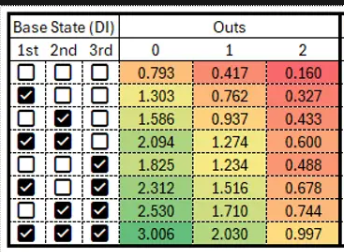

In [ ]:
import pandas as pd

# File path
file_path = r"C:\Users\TrevorWhite\Downloads\re288.xlsx"

# Load the Excel file
re288 = pd.read_excel(file_path)

# Drop the 'Pitch count ->' column if it exists
re288 = re288.drop(columns=['Pitch count ->'], errors='ignore')

# Reshape the dataframe so that count columns become rows
re288 = re288.melt(id_vars=['ManOn1st', 'ManOn2nd', 'ManOn3rd','outs'], 
                    var_name="Count", 
                    value_name="Value")

# Display first few rows
re288.head(111)


In [ ]:
# Fill missing values with 0
combined_df[['ManOn1st', 'ManOn2nd', 'ManOn3rd']] = combined_df[['ManOn1st', 'ManOn2nd', 'ManOn3rd']].fillna(0)
re288[['ManOn1st', 'ManOn2nd', 'ManOn3rd']] = re288[['ManOn1st', 'ManOn2nd', 'ManOn3rd']].fillna(0)

# Print first few 


# Display first few rows to verify
print("Updated Combined Data:")
combined_df.head()



In [ ]:
import pandas as pd
import numpy as np

# --- Data Type Optimization ---
# Rename 'count' to 'Count' (in place) and set as category
combined_df.rename(columns={'count': 'Count'}, inplace=True)
combined_df['Count'] = combined_df['Count'].astype('category')
re288['Count'] = re288['Count'].astype('category')

# Convert ManOn1st, ManOn2nd, ManOn3rd to smaller integer types
for col in ['ManOn1st', 'ManOn2nd', 'ManOn3rd']:
    combined_df[col] = combined_df[col].astype('int8')
    re288[col] = re288[col].astype('int8')

# Keep only necessary columns in combined_df for efficient merging
required_cols = ['uniqPitchId', 'Count','outs', 'ManOn1st', 'ManOn2nd', 'ManOn3rd', 
                 'Conf', 'Runs', 'pitchResult', 'atbatDesc','inn']
combined_df = combined_df[required_cols]

# --- Merge in Batches ---
# Split combined_df into 5 chunks
chunks = np.array_split(combined_df, 5)

merged_chunks = []
for chunk in chunks:
    merged_chunk = chunk.merge(re288, on=['Count','outs', 'ManOn1st', 'ManOn2nd', 'ManOn3rd'], how='left')
    merged_chunks.append(merged_chunk)

# Concatenate all merged chunks
merged_df = pd.concat(merged_chunks, ignore_index=True)

# Display the first few rows to verify
merged_df.head()


In [ ]:
import pandas as pd
import numpy as np

# --- Data Type Optimization ---
# Rename 'count' to 'Count' in combined_df and convert it to category (kept but not used in join)
combined_df.rename(columns={'count': 'Count'}, inplace=True)
combined_df['Count'] = combined_df['Count'].astype('category')
#re24['Count'] = re24['Count'].astype('category')

# Convert ManOn1st, ManOn2nd, and ManOn3rd to smaller integer types in both DataFrames
for col in ['ManOn1st', 'ManOn2nd', 'ManOn3rd']:
    combined_df[col] = combined_df[col].astype('int8')
    re24[col] = re24[col].astype('int8')

# (Optional) Convert 'outs' to a smaller integer type if needed
combined_df['outs'] = combined_df['outs'].astype('int8')
re24['outs'] = re24['outs'].astype('int8')

# Keep only necessary columns in combined_df for efficient merging
required_cols = ['uniqPitchId', 'Count', 'outs', 'ManOn1st', 'ManOn2nd', 'ManOn3rd', 
                 'Conf', 'Runs', 'pitchResult', 'atbatDesc', 'inn','abNumInGame','batterId','gameId']
combined_df = combined_df[required_cols]

# --- Merge in Batches ---
# Split combined_df into 5 chunks to reduce memory usage during the merge
chunks = np.array_split(combined_df, 5)

merged_chunks = []
for chunk in chunks:
    # Join on 'outs' and the three ManOn columns (do not join on 'Count')
    merged_chunk = chunk.merge(re24, on=['outs', 'ManOn1st', 'ManOn2nd', 'ManOn3rd'], how='left')
    merged_chunks.append(merged_chunk)

# Concatenate all merged chunks into a single DataFrame
merged_re24 = pd.concat(merged_chunks, ignore_index=True)

# Display the first few rows to verify
merged_re24.head()

In [ ]:
import pandas as pd

# Ensure we have the necessary columns
required_cols = {'inn', 'abNumInGame', 'batterId', 'gameId'}
if required_cols.issubset(merged_re24.columns):
    
    # Step 1: Extract team indicator and inning number from 'inn'
    # Example: "Top 1" → TopBot="Top", InningNumber=1; "Bot 1" → TopBot="Bot", InningNumber=1
    merged_re24['TopBot'] = merged_re24['inn'].str.extract(r'^(Top|Bot)', expand=False)
    merged_re24['InningNumber'] = merged_re24['inn'].str.extract(r'(\d+)$', expand=False).astype(int)
    
    # Step 2: Sort the DataFrame by game, inning, team, and abNumInGame
    merged_re24 = merged_re24.sort_values(by=['gameId', 'InningNumber', 'TopBot', 'abNumInGame']).copy()
    
    # Step 3: For each game and team (Top/Bot), assign a batting order number that:
    #   - Starts at 1 for the first unique batter encountered in the game.
    #   - Increments for each new batter.
    #   - Cycles back to 1 after reaching 9.
    # We use groupby on ['gameId', 'TopBot'] so the count is cumulative across innings.
    merged_re24['NumInOrder'] = merged_re24.groupby(['gameId', 'TopBot'])['batterId'] \
        .transform(lambda x: (pd.factorize(x)[0] % 9) + 1)
    
    print("NumInOrder column successfully added!")
    print(merged_re24.head())
else:
    print("Required columns are missing from the dataset!")


In [ ]:
print(merged_re24.shape[0])

# Print the count
merged_df[merged_df['Value'].isna()][['Count','pitchResult' ,'ManOn1st', 'ManOn2nd', 'ManOn3rd']].drop_duplicates().head(111)


In [ ]:
merged_df = merged_df.dropna(subset=['Value'])

# Print first few rows to verify
print(len(merged_df))

In [ ]:
import pandas as pd

# Extract numeric inning while preserving 'Top'/'Bot' distinction
merged_re24['inn_num'] = merged_re24['inn'].str.extract(r'(\d+)').astype(int)  # Extract just the inning number
merged_re24['inn_half'] = merged_re24['inn'].str[:3]  # Keeps 'Top' or 'Bot' as a separate column

# Split 'uniqPitchId' into game_id, plate appearance (pa), and pitch number
merged_re24[['game_id', 'pa', 'pitch_no']] = merged_re24['uniqPitchId'].str.split('-', expand=True)
merged_re24['pa'] = merged_re24['pa'].astype(int)
merged_re24['pitch_no'] = merged_re24['pitch_no'].astype(int)

# Sort by game_id, inn_num, inn_half (Top/Bottom), pa, and pitch_no to ensure correct order
merged_re24 = merged_re24.sort_values(['game_id', 'inn_num', 'inn_half', 'pa', 'pitch_no'])

# Get the next pitch's Value only within the same inning half (Top/Bottom)
merged_re24['next_value'] = merged_re24.groupby(['game_id', 'inn_num', 'inn_half'])['Run_Expectancy'].shift(-1)

# 5. For the last pitch in each inning half, set next_value to 0 (instead of NaN)
merged_re24['next_value'] = merged_re24['next_value'].fillna(0)

# Compute value difference between current pitch and the next pitch (only if within the same inning half)
merged_re24['re_diff'] = merged_re24['next_value'] - merged_re24['Run_Expectancy'] + merged_re24['Runs']

# (Optional) Drop helper columns if no longer needed
merged_re24.drop(columns=['next_value', 'game_id', 'pa', 'pitch_no', 'inn_num', 'inn_half'], inplace=True)

# Display first few rows to verify
merged_re24[['uniqPitchId', 'inn', 'Run_Expectancy', 're_diff']].head(10)


In [ ]:
import pandas as pd

# Extract numeric inning while preserving 'Top'/'Bot' distinction
merged_df['inn_num'] = merged_df['inn'].str.extract(r'(\d+)').astype(int)  # Extracts just the inning number
merged_df['inn_half'] = merged_df['inn'].str[:3]  # Keeps 'Top' or 'Bot' as a separate column

# Split 'uniqPitchId' into game_id, plate appearance (pa), and pitch number
merged_df[['game_id', 'pa', 'pitch_no']] = merged_df['uniqPitchId'].str.split('-', expand=True)
merged_df['pa'] = merged_df['pa'].astype(int)
merged_df['pitch_no'] = merged_df['pitch_no'].astype(int)

# Sort by game_id, inn_num, inn_half (Top/Bottom), pa, and pitch_no to ensure correct order
merged_df = merged_df.sort_values(['game_id', 'inn_num', 'inn_half', 'pa', 'pitch_no'])

# Get the next pitch's Value only within the same inning half (Top/Bottom)
merged_df['next_value'] = merged_df.groupby(['game_id', 'inn_num', 'inn_half'])['Value'].shift(-1)


# Compute value difference between current pitch and the next pitch (only if within the same inning half)
merged_df['value_diff'] = merged_df['next_value'] - merged_df['Value']

# (Optional) Drop helper columns if no longer needed
merged_df.drop(columns=['next_value', 'game_id', 'pa', 'pitch_no', 'inn_num', 'inn_half'], inplace=True)

# Display first few rows to verify
print(merged_df[['uniqPitchId', 'inn', 'Value', 'value_diff']].head(10))


In [ ]:
print(merged_df[merged_df['value_diff'].isna()][['Count','pitchResult' ,'ManOn1st', 'ManOn2nd', 'ManOn3rd']].drop_duplicates().shape[0])

# Print the count
merged_df[merged_df['value_diff'].isna()][['Count','uniqPitchId','value_diff','Value','pitchResult' ,'ManOn1st', 'ManOn2nd', 'ManOn3rd']].drop_duplicates().head(111)


In [ ]:
merged_re24[
    merged_re24['uniqPitchId'].str.contains("100037093", na=False) &
    merged_re24['inn'].str.contains("Top", na=False)
].head(1111)

In [ ]:
merged_re24[ 
    (merged_re24['ManOn1st'] == 1) & 
    (merged_re24['ManOn2nd'] == 1) & 
    (merged_re24['ManOn3rd'] == 1) & (merged_re24['value_diff'] != 0)
].head(100)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Filter for nonzero re_diff ---
df_nonzero = merged_re24[merged_re24['re_diff'] != 0].copy()

# --- Create Bunt Indicator ---
df_nonzero['Bunt'] = df_nonzero['pitchResult'].str.contains('bunt', case=False, na=False)
df_nonzero['BuntLabel'] = df_nonzero['Bunt'].map({True: 'bunt', False: 'no bunt'})

# --- Filter non-bunt rows based on NumInOrder (< 6) while keeping all bunt rows ---
df_nonzero = df_nonzero[(df_nonzero['BuntLabel'] == 'bunt') | 
                        ((df_nonzero['BuntLabel'] == 'no bunt') & (df_nonzero['NumInOrder'] < 5))]

# --- Create Situation Indicators ---
df_nonzero['Bases Loaded'] = (
    (df_nonzero['ManOn1st'] == 1) & 
    (df_nonzero['ManOn2nd'] == 1) & 
    (df_nonzero['ManOn3rd'] == 1)
)

df_nonzero['2nd-3rd'] = (
    (df_nonzero['ManOn2nd'] == 1) & (df_nonzero['ManOn3rd'] == 1) & (df_nonzero['ManOn1st'] == 0)
)

df_nonzero['1st'] = (
    (df_nonzero['ManOn1st'] == 1) & 
    (df_nonzero['ManOn2nd'] == 0) & 
    (df_nonzero['ManOn3rd'] == 0)
)

df_nonzero['2nd'] = (
    (df_nonzero['ManOn2nd'] == 1) & 
    (df_nonzero['ManOn3rd'] == 0)
)

df_nonzero['3rd'] = (
    (df_nonzero['ManOn3rd'] == 1) & 
    (df_nonzero['ManOn2nd'] == 0) &
    (df_nonzero['ManOn1st'] == 0)
)

df_nonzero['1st-3rd'] = (
    (df_nonzero['ManOn3rd'] == 1) & 
    (df_nonzero['ManOn2nd'] == 0) &
    (df_nonzero['ManOn1st'] == 1)
)


df_nonzero['Bases Empty'] = (
    (df_nonzero['ManOn3rd'] == 0) & 
    (df_nonzero['ManOn2nd'] == 0) &
    (df_nonzero['ManOn1st'] == 0)
)

# --- Reshape Data so Each Situation is Independent ---
situation_cols = ['Bases Loaded', '2nd-3rd', '1st', '2nd', '3rd','1st-3rd', 'Bases Empty']
df_melt = df_nonzero.melt(
    id_vars=['uniqPitchId', 're_diff', 'BuntLabel', 'outs'],
    value_vars=situation_cols,
    var_name='Situation',
    value_name='isSituation'
)

# Keep only rows where the situation indicator is True
df_melt = df_melt[df_melt['isSituation']]

# --- Grouping & Aggregation ---
grouped = df_melt.groupby(['Situation', 'BuntLabel', 'outs']).agg(
    PA=('uniqPitchId', 'count'),
    RV=('re_diff', 'mean')
).reset_index()

# --- Pivot the Data ---
pivoted = grouped.pivot_table(
    index=['Situation', 'outs'],
    columns='BuntLabel',
    values=['PA', 'RV'],
    fill_value=0
)

pivoted.columns = [f"{stat} {bunt}" for stat, bunt in pivoted.columns]
pivoted = pivoted.reset_index()

# Filter out groups with low sample size (e.g., less than 20 bunt plate appearances)
pivoted = pivoted[pivoted['PA bunt'] > 20]

# --- Create Labels for X-Axis ---
pivoted['group_label'] = pivoted.apply(
    lambda row: f"{row['Situation']} (Outs: {row['outs']})", axis=1
)

# --- Plot Average RV Comparison (Bunt vs No Bunt) with Sample Size ---
situations = pivoted['group_label']
x = range(len(situations))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

rv_no_bunt = pivoted.get('RV no bunt', pd.Series(0, index=pivoted.index))
rv_bunt = pivoted.get('RV bunt', pd.Series(0, index=pivoted.index))

pa_no_bunt = pivoted.get('PA no bunt', pd.Series(0, index=pivoted.index))
pa_bunt = pivoted.get('PA bunt', pd.Series(0, index=pivoted.index))

bars_no_bunt = ax.bar([i - width/2 for i in x], rv_no_bunt, width, label='RV no bunt')
bars_bunt = ax.bar([i + width/2 for i in x], rv_bunt, width, label='RV bunt')

# Annotate bars with sample size (n = count)
# for bar, count in zip(bars_no_bunt, pa_no_bunt):
#     ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05, f"n={int(count)}", 
#             ha='center', va='bottom', fontsize=7, color='black')

for bar, count in zip(bars_bunt, pa_bunt):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + .01, f"n={int(count)}", 
            ha='center', va='bottom', fontsize=7, color='black')

# Final plot adjustments
ax.set_xticks(x)
ax.set_xticklabels(situations, rotation=45, ha='right')
ax.set_ylabel('Average Run Value (RV)')
ax.set_title('Average Run Value by Bunt Status, Situation, and Outs')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Add a column for the difference between 'RV no bunt' and 'RV bunt'
pivoted['RV Difference'] = pivoted['RV no bunt'] - pivoted['RV bunt']

# Format the text column based on RV Difference
pivoted['Bunting Comparison'] = pivoted['RV Difference'].apply(
    lambda x: f"Bunting is {abs(x):.2f} {'more' if x < 0 else 'less'} effective than swinging away"
)






# filtered_pivoted.head()
pivoted.sort_values(by=['Situation'], ascending=False).head(100)


In [ ]:
pivoted[['Situation', 'outs', 'RV Difference', 'PA bunt']].head(111)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

# Select relevant columns
df_plot = pivoted[['Situation', 'outs', 'RV Difference', 'PA bunt']].copy()

# Reverse and round "RV Difference" to 2 decimals
df_plot['RV Difference'] = df_plot['RV Difference'].round(2)# * -1

# Normalize "RV Difference" with a fixed range (-0.2 to 0.2)
rv_min, rv_max = -0.2, 0.2
df_plot['RV_norm'] = ((df_plot['RV Difference'] - rv_min) / (rv_max - rv_min)).clip(0, 1)

# Create figure and axis for the table plot
fig, ax = plt.subplots(figsize=(10, len(df_plot) * 0.5))
ax.set_frame_on(False)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

# Prepare table data and column labels (excluding normalized column)
cell_text = df_plot[['Situation', 'outs', 'RV Difference', 'PA bunt']].values
col_labels = ['Situation', 'outs', 'RV Difference', 'PA bunt']

# Create table plot
table = plt.table(cellText=cell_text, colLabels=col_labels, cellLoc='center', loc='center')

# ---- Autofit column widths based on text length ----
def get_max_text_length(col_index):
    texts = [str(col_labels[col_index])] + [str(item) for item in df_plot.iloc[:, col_index]]
    return max(len(text) for text in texts)

# Compute maximum text length for each column
col_widths = [get_max_text_length(j) for j in range(len(col_labels))]
total_width = sum(col_widths)
# Normalize widths so that they sum to 1
norm_widths = [w / total_width for w in col_widths]

# Set each cell's width based on its column's normalized width
for (row, col), cell in table.get_celld().items():
    if col < len(norm_widths):
        cell.set_width(norm_widths[col])

# Apply background colors to specific cells
for i in range(len(df_plot)):
    for j in range(len(col_labels)):
        cell = table[i + 1, j]  # Offset by 1 for header row

        # For "RV Difference" (column index 2): use coolwarm colormap
        if j == 2:
            norm_val = df_plot.iloc[i]['RV_norm']
            color = cm.coolwarm(norm_val)
            cell.set_facecolor(color)

        # For "PA bunt" (column index 3): color light red if value < 100
        if j == 3:
            pa_value = df_plot.iloc[i]['PA bunt']
            if pa_value < 100:
                cell.set_facecolor("lightcoral")

plt.tight_layout()
plt.show()


In [ ]:
df_filtered = merged_re24[~merged_re24['pitchResult'].str.contains("Home Run", case=False, na=False)]
avg_re_diff = df_filtered.groupby('pitchResult')['re_diff'].mean().reset_index()
avg_re_diff = avg_re_diff.sort_values(by='re_diff', ascending=False)  # Order by re_diff descending
print(avg_re_diff)


In [ ]:
# Step 1: Ensure 'Count' column exists and split into 'balls' and 'strikes'
if 'Count' in merged_re24.columns:
    merged_re24[['balls', 'strikes']] = merged_re24['Count'].str.split('-', expand=True).astype(float)

# Step 2: Filter for bunt-related pitch results
df_bunts = merged_re24[merged_re24['pitchResult'].str.contains("bunt", case=False, na=False)]

# Step 3: Calculate # occurrences and % by strikes
bunt_counts = df_bunts.groupby('strikes').size().reset_index(name='Occurrences')  # Rename properly
bunt_counts['Percentage'] = (bunt_counts['Occurrences'] / bunt_counts['Occurrences'].sum()) * 100

# Step 4: Display results
print(bunt_counts)


In [ ]:
comb.head(1)

This indicates that the rate of getting a bunt down is no better than 67% per strike
it is likely 5-20% lower as after failing once a hitter will just swing away

In [ ]:
# Step 1: Filter for USD batting team
usd_df = comb[comb['battingTeam'] == "USD"].copy()
# print(usd_df.head())  # Display first few rows

# Step 2: Ensure 'Count' column exists and split into 'balls' and 'strikes'
if 'count' in usd_df.columns:
    usd_df[['balls', 'strikes']] = usd_df['count'].str.split('-', expand=True).astype(float)

# Step 3: Filter for bunt-related pitch results
df_bunts_usd = usd_df[usd_df['pitchResult'].str.contains("bunt", case=False, na=False)]

# Step 4: Calculate # occurrences and % by strikes
bunt_counts_usd = df_bunts_usd.groupby('strikes').size().reset_index(name='Occurrences')
bunt_counts_usd['Percentage'] = (bunt_counts_usd['Occurrences'] / bunt_counts_usd['Occurrences'].sum()) * 100

# Step 5: Display results
print(bunt_counts_usd)


This indicates that the rate of getting a bunt down is no better than 75% per strike
it is likely 5-20% lower as after failing once a hitter will just swing away
and these % also dont capture the ultimate failure if they just kept bunting
this we will assume is about 3% 



the effects of this depend on our strategy, in the past, after failing a bunt attempt, 
how often would we give up and just swing away?


This question also stands for our approach moving forward, 
how often will we stop a bunt call after 1 strike, 2?

This would allow me to estimate how often we'd see the results of getting a bunt down vs the alternative


% getting bunt down (no quit)= (1- .73)))^3   = .02   --2% of the time we have a completely unproductive out, how would that affect our bunt results


this should be largely reflective as by assuming there's no quit we handle the case of quiting vs not 
by assuming its a net zero decision









In [ ]:
unique_pitch_results = df_bunts['pitchResult'].unique()
print(unique_pitch_results)


In [ ]:
# Ensure pandas displays all columns and rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.expand_frame_repr', False) 